Meta-iteration 0: Gen loss 0.6417, Disc loss 1.3013
Meta-iteration 100: Gen loss 0.6429, Disc loss 1.3512
Meta-iteration 200: Gen loss 0.6380, Disc loss 1.3617
Meta-iteration 300: Gen loss 0.6438, Disc loss 1.3367
Meta-iteration 400: Gen loss 0.6402, Disc loss 1.3407
Meta-iteration 500: Gen loss 0.6415, Disc loss 1.3286
Meta-iteration 600: Gen loss 0.6388, Disc loss 1.3616
Meta-iteration 700: Gen loss 0.6381, Disc loss 1.3680
Meta-iteration 800: Gen loss 0.6384, Disc loss 1.3489
Meta-iteration 900: Gen loss 0.6426, Disc loss 1.3313


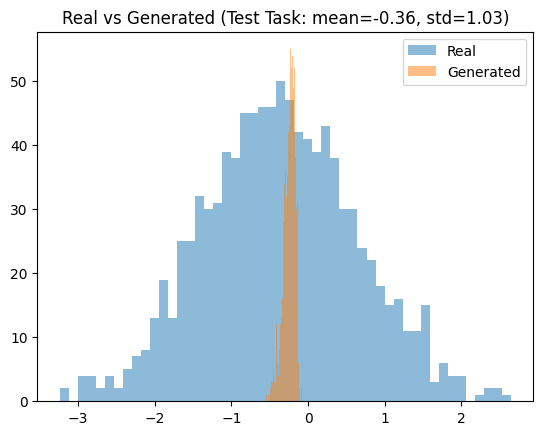

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Generator network
class Generator(nn.Module):
    def __init__(self, noise_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, z):
        return self.net(z)

# Discriminator network
class Discriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# Function to sample a task (e.g., a Gaussian with random mean and std)
def sample_task():
    mean = np.random.uniform(-1, 1)
    std = np.random.uniform(0.5, 1.5)
    def task(batch_size):
        return torch.tensor(np.random.normal(mean, std, size=(batch_size, 1)), dtype=torch.float32)
    return task, mean, std

# MAML-GAN training loop skeleton
def maml_gan_train(
    meta_iterations=1000,
    tasks_per_meta_batch=4,
    inner_steps=5,
    inner_lr=0.01,
    outer_lr=0.0005,
    noise_dim=5,
    hidden_dim=64,
    batch_size=32
):
    # Meta-parameters (shared across tasks)
    generator = Generator(noise_dim, hidden_dim, 1)
    discriminator = Discriminator(1, hidden_dim)
    meta_gen_opt = optim.Adam(generator.parameters(), lr=outer_lr)
    meta_disc_opt = optim.Adam(discriminator.parameters(), lr=outer_lr)

    for meta_iter in range(meta_iterations):
        meta_gen_loss = 0.0
        meta_disc_loss = 0.0
        for _ in range(tasks_per_meta_batch):
            # Sample a new task
            task, mean, std = sample_task()
            # Clone models for inner loop
            gen_clone = Generator(noise_dim, hidden_dim, 1)
            disc_clone = Discriminator(1, hidden_dim)
            gen_clone.load_state_dict(generator.state_dict())
            disc_clone.load_state_dict(discriminator.state_dict())
            gen_opt = optim.SGD(gen_clone.parameters(), lr=inner_lr)
            disc_opt = optim.SGD(disc_clone.parameters(), lr=inner_lr)
            # Inner loop: GAN training for this task
            for _ in range(inner_steps):
                # Real data
                real_data = task(batch_size)
                # Fake data
                z = torch.randn(batch_size, noise_dim)
                fake_data = gen_clone(z)
                # Discriminator loss
                disc_real = disc_clone(real_data)
                disc_fake = disc_clone(fake_data.detach())
                disc_loss = -torch.mean(torch.log(disc_real + 1e-8) + torch.log(1 - disc_fake + 1e-8))
                disc_opt.zero_grad()
                disc_loss.backward()
                disc_opt.step()
                # Generator loss
                z = torch.randn(batch_size, noise_dim)
                fake_data = gen_clone(z)
                disc_fake = disc_clone(fake_data)
                gen_loss = -torch.mean(torch.log(disc_fake + 1e-8))
                gen_opt.zero_grad()
                gen_loss.backward()
                gen_opt.step()
            # Compute post-adaptation loss for meta-update
            z = torch.randn(batch_size, noise_dim)
            fake_data = gen_clone(z)
            real_data = task(batch_size)
            disc_real = disc_clone(real_data)
            disc_fake = disc_clone(fake_data)
            task_disc_loss = -torch.mean(torch.log(disc_real + 1e-8) + torch.log(1 - disc_fake + 1e-8))
            task_gen_loss = -torch.mean(torch.log(disc_fake + 1e-8))
            meta_gen_loss += task_gen_loss
            meta_disc_loss += task_disc_loss
        # Outer loop: meta-update
        meta_gen_opt.zero_grad()
        meta_disc_opt.zero_grad()
        (meta_gen_loss / tasks_per_meta_batch).backward(retain_graph=True)
        (meta_disc_loss / tasks_per_meta_batch).backward()
        meta_gen_opt.step()
        meta_disc_opt.step()
        if meta_iter % 100 == 0:
            print(f"Meta-iteration {meta_iter}: Gen loss {meta_gen_loss.item() / tasks_per_meta_batch:.4f}, Disc loss {meta_disc_loss.item() / tasks_per_meta_batch:.4f}")

    # After training, visualize generator output vs. real data for a new task
    task, mean, std = sample_task()
    real_samples = task(1000).detach().numpy()
    z = torch.randn(1000, noise_dim)
    with torch.no_grad():
        gen_samples = generator(z).detach().numpy()
    plt.hist(real_samples, bins=50, alpha=0.5, label='Real')
    plt.hist(gen_samples, bins=50, alpha=0.5, label='Generated')
    plt.title(f"Real vs Generated (Test Task: mean={mean:.2f}, std={std:.2f})")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    maml_gan_train()

Meta-iteration 0: Gen loss 0.4982, Disc loss -0.6366
Sample generated values at meta-iteration 0: [ 0.09162933  0.02247184  0.08375016 -0.01261234  0.05828871]
Meta-iteration 100: Gen loss 0.2090, Disc loss -0.3162
Meta-iteration 200: Gen loss -0.0984, Disc loss 0.2428
Meta-iteration 300: Gen loss -0.0852, Disc loss 0.0148
Meta-iteration 400: Gen loss 0.2280, Disc loss -0.2412
Meta-iteration 500: Gen loss 0.2626, Disc loss -0.2017
Sample generated values at meta-iteration 500: [0.07339202 0.09760825 0.16931792 0.15856138 0.24310708]
Meta-iteration 600: Gen loss 0.0978, Disc loss -0.0765
Meta-iteration 700: Gen loss -0.0117, Disc loss -0.0201
Meta-iteration 800: Gen loss 0.4361, Disc loss -0.3787
Meta-iteration 900: Gen loss -0.0036, Disc loss 0.0947
Meta-iteration 1000: Gen loss 0.0692, Disc loss -0.1123
Sample generated values at meta-iteration 1000: [0.15296039 0.09967673 0.15736687 0.04799392 0.01583556]
Meta-iteration 1100: Gen loss 0.2900, Disc loss -0.3856
Meta-iteration 1200: Ge

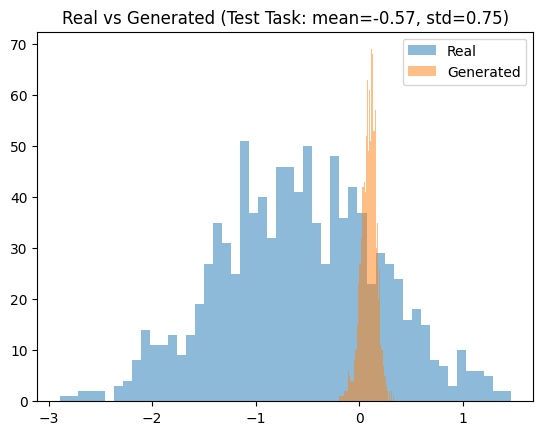

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Generator network
class Generator(nn.Module):
    def __init__(self, noise_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, z):
        return self.net(z)

# Discriminator network (no sigmoid for WGAN)
class Discriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)

# Function to sample a task (e.g., a Gaussian with random mean and std)
def sample_task():
    mean = np.random.uniform(-1, 1)
    std = np.random.uniform(0.5, 1.5)
    def task(batch_size):
        return torch.tensor(np.random.normal(mean, std, size=(batch_size, 1)), dtype=torch.float32)
    return task, mean, std

# MAML-GAN training loop skeleton
def maml_gan_train(
    meta_iterations=2000,  # Increased meta-iterations
    tasks_per_meta_batch=4,
    inner_steps=20,  # Increased inner steps
    inner_lr=0.01,
    outer_lr=0.0005,
    noise_dim=5,
    hidden_dim=64,
    batch_size=32,
    clip_value=0.1  # Increased WGAN weight clipping
):
    # Meta-parameters (shared across tasks)
    generator = Generator(noise_dim, hidden_dim, 1)
    discriminator = Discriminator(1, hidden_dim)
    meta_gen_opt = optim.Adam(generator.parameters(), lr=outer_lr)
    meta_disc_opt = optim.Adam(discriminator.parameters(), lr=outer_lr)

    for meta_iter in range(meta_iterations):
        meta_gen_loss = 0.0
        meta_disc_loss = 0.0
        for _ in range(tasks_per_meta_batch):
            # Sample a new task
            task, mean, std = sample_task()
            # Clone models for inner loop
            gen_clone = Generator(noise_dim, hidden_dim, 1)
            disc_clone = Discriminator(1, hidden_dim)
            gen_clone.load_state_dict(generator.state_dict())
            disc_clone.load_state_dict(discriminator.state_dict())
            # Use Adam optimizer for inner loop
            gen_opt = optim.Adam(gen_clone.parameters(), lr=inner_lr)
            disc_opt = optim.Adam(disc_clone.parameters(), lr=inner_lr)
            # Inner loop: GAN training for this task
            for _ in range(inner_steps):
                # Real data
                real_data = task(batch_size)
                # Fake data
                z = torch.randn(batch_size, noise_dim)
                fake_data = gen_clone(z)
                # Discriminator loss (WGAN)
                disc_real = disc_clone(real_data)
                disc_fake = disc_clone(fake_data.detach())
                disc_loss = -(torch.mean(disc_real) - torch.mean(disc_fake))
                disc_opt.zero_grad()
                disc_loss.backward()
                disc_opt.step()
                # Weight clipping for WGAN
                for p in disc_clone.parameters():
                    p.data.clamp_(-clip_value, clip_value)
                # Generator loss (WGAN)
                z = torch.randn(batch_size, noise_dim)
                fake_data = gen_clone(z)
                disc_fake = disc_clone(fake_data)
                gen_loss = -torch.mean(disc_fake)
                gen_opt.zero_grad()
                gen_loss.backward()
                gen_opt.step()
            # Compute post-adaptation loss for meta-update (WGAN)
            z = torch.randn(batch_size, noise_dim)
            fake_data = gen_clone(z)
            real_data = task(batch_size)
            disc_real = disc_clone(real_data)
            disc_fake = disc_clone(fake_data)
            task_disc_loss = -(torch.mean(disc_real) - torch.mean(disc_fake))
            task_gen_loss = -torch.mean(disc_fake)
            meta_gen_loss += task_gen_loss
            meta_disc_loss += task_disc_loss
        # Outer loop: meta-update
        meta_gen_opt.zero_grad()
        meta_disc_opt.zero_grad()
        (meta_gen_loss / tasks_per_meta_batch).backward(retain_graph=True)
        (meta_disc_loss / tasks_per_meta_batch).backward()
        meta_gen_opt.step()
        meta_disc_opt.step()
        # Weight clipping for WGAN
        for p in discriminator.parameters():
            p.data.clamp_(-clip_value, clip_value)
        if meta_iter % 100 == 0:
            print(f"Meta-iteration {meta_iter}: Gen loss {meta_gen_loss.item() / tasks_per_meta_batch:.4f}, Disc loss {meta_disc_loss.item() / tasks_per_meta_batch:.4f}")
        # Print a few generated samples every 500 meta-iterations
        if meta_iter % 500 == 0:
            z = torch.randn(5, noise_dim)
            with torch.no_grad():
                gen_samples = generator(z).detach().cpu().numpy().flatten()
            print(f"Sample generated values at meta-iteration {meta_iter}: {gen_samples}")

    # After training, visualize generator output vs. real data for a new task
    task, mean, std = sample_task()
    real_samples = task(1000).detach().numpy()
    z = torch.randn(1000, noise_dim)
    with torch.no_grad():
        gen_samples = generator(z).detach().numpy()
    plt.hist(real_samples, bins=50, alpha=0.5, label='Real')
    plt.hist(gen_samples, bins=50, alpha=0.5, label='Generated')
    plt.title(f"Real vs Generated (Test Task: mean={mean:.2f}, std={std:.2f})")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    maml_gan_train()

Meta-iteration 0: Gen loss 0.1251, Disc loss -0.1339
Sample generated values at meta-iteration 0: [0.15140168 0.12976393 0.10163284 0.02191047 0.09513814]
Meta-iteration 100: Gen loss -0.2859, Disc loss 0.2159
Meta-iteration 200: Gen loss 0.3256, Disc loss -0.3038
Meta-iteration 300: Gen loss 0.0068, Disc loss 0.0151
Meta-iteration 400: Gen loss -0.2654, Disc loss -0.0935
Meta-iteration 500: Gen loss 0.2788, Disc loss 0.0017
Sample generated values at meta-iteration 500: [ 0.03438394  0.17039521  0.151428    0.13265926 -0.00870304]
Meta-iteration 600: Gen loss -0.2196, Disc loss 0.2049
Meta-iteration 700: Gen loss -0.0887, Disc loss 0.1482
Meta-iteration 800: Gen loss 0.3087, Disc loss -0.4267
Meta-iteration 900: Gen loss -0.2004, Disc loss -0.0910
Meta-iteration 1000: Gen loss -0.4034, Disc loss 0.3069
Sample generated values at meta-iteration 1000: [0.0896538  0.2393177  0.05477132 0.17105079 0.20799366]
Meta-iteration 1100: Gen loss -0.0184, Disc loss 0.1159
Meta-iteration 1200: Gen

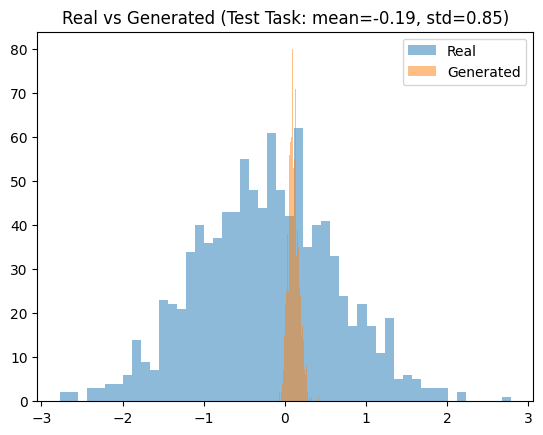

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Generator network (conditioned on mean and std)
class Generator(nn.Module):
    def __init__(self, noise_dim, cond_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim + cond_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, z, cond):
        # z: (batch, noise_dim), cond: (batch, cond_dim)
        x = torch.cat([z, cond], dim=1)
        return self.net(x)

# Discriminator network (conditioned on mean and std)
class Discriminator(nn.Module):
    def __init__(self, input_dim, cond_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + cond_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x, cond):
        # x: (batch, input_dim), cond: (batch, cond_dim)
        inp = torch.cat([x, cond], dim=1)
        return self.net(inp)

# Function to sample a task (e.g., a Gaussian with random mean and std)
def sample_task():
    mean = np.random.uniform(-1, 1)
    std = np.random.uniform(0.5, 1.5)
    def task(batch_size):
        return torch.tensor(np.random.normal(mean, std, size=(batch_size, 1)), dtype=torch.float32)
    return task, mean, std

# MAML-GAN training loop skeleton
def maml_gan_train(
    meta_iterations=2000,
    tasks_per_meta_batch=4,
    inner_steps=20,  # Increased inner steps
    inner_lr=0.01,
    outer_lr=0.0005,
    noise_dim=5,
    cond_dim=2,  # mean and std
    hidden_dim=64,
    batch_size=64,  # Increased batch size
    clip_value=0.1
):
    # Meta-parameters (shared across tasks)
    generator = Generator(noise_dim, cond_dim, hidden_dim, 1)
    discriminator = Discriminator(1, cond_dim, hidden_dim)
    meta_gen_opt = optim.Adam(generator.parameters(), lr=outer_lr)
    meta_disc_opt = optim.Adam(discriminator.parameters(), lr=outer_lr)

    for meta_iter in range(meta_iterations):
        meta_gen_loss = 0.0
        meta_disc_loss = 0.0
        for _ in range(tasks_per_meta_batch):
            # Sample a new task
            task, mean, std = sample_task()
            # Prepare conditioning vector for the batch
            cond = torch.tensor([[mean, std]] * batch_size, dtype=torch.float32)
            # Clone models for inner loop
            gen_clone = Generator(noise_dim, cond_dim, hidden_dim, 1)
            disc_clone = Discriminator(1, cond_dim, hidden_dim)
            gen_clone.load_state_dict(generator.state_dict())
            disc_clone.load_state_dict(discriminator.state_dict())
            gen_opt = optim.Adam(gen_clone.parameters(), lr=inner_lr)
            disc_opt = optim.Adam(disc_clone.parameters(), lr=inner_lr)
            # Inner loop: GAN training for this task
            for _ in range(inner_steps):
                # Real data
                real_data = task(batch_size)
                # Fake data
                z = torch.randn(batch_size, noise_dim)
                fake_data = gen_clone(z, cond)
                # Discriminator loss (WGAN)
                disc_real = disc_clone(real_data, cond)
                disc_fake = disc_clone(fake_data.detach(), cond)
                disc_loss = -(torch.mean(disc_real) - torch.mean(disc_fake))
                disc_opt.zero_grad()
                disc_loss.backward()
                disc_opt.step()
                # Weight clipping for WGAN
                for p in disc_clone.parameters():
                    p.data.clamp_(-clip_value, clip_value)
                # Generator loss (WGAN)
                z = torch.randn(batch_size, noise_dim)
                fake_data = gen_clone(z, cond)
                disc_fake = disc_clone(fake_data, cond)
                gen_loss = -torch.mean(disc_fake)
                gen_opt.zero_grad()
                gen_loss.backward()
                gen_opt.step()
            # Compute post-adaptation loss for meta-update (WGAN)
            z = torch.randn(batch_size, noise_dim)
            fake_data = gen_clone(z, cond)
            real_data = task(batch_size)
            disc_real = disc_clone(real_data, cond)
            disc_fake = disc_clone(fake_data, cond)
            task_disc_loss = -(torch.mean(disc_real) - torch.mean(disc_fake))
            task_gen_loss = -torch.mean(disc_fake)
            meta_gen_loss += task_gen_loss
            meta_disc_loss += task_disc_loss
        # Outer loop: meta-update
        meta_gen_opt.zero_grad()
        meta_disc_opt.zero_grad()
        (meta_gen_loss / tasks_per_meta_batch).backward(retain_graph=True)
        (meta_disc_loss / tasks_per_meta_batch).backward()
        meta_gen_opt.step()
        meta_disc_opt.step()
        # Weight clipping for WGAN
        for p in discriminator.parameters():
            p.data.clamp_(-clip_value, clip_value)
        if meta_iter % 100 == 0:
            print(f"Meta-iteration {meta_iter}: Gen loss {meta_gen_loss.item() / tasks_per_meta_batch:.4f}, Disc loss {meta_disc_loss.item() / tasks_per_meta_batch:.4f}")
        # Print a few generated samples every 500 meta-iterations
        if meta_iter % 500 == 0:
            z = torch.randn(5, noise_dim)
            cond = torch.tensor([[mean, std]] * 5, dtype=torch.float32)
            with torch.no_grad():
                gen_samples = generator(z, cond).detach().cpu().numpy().flatten()
            print(f"Sample generated values at meta-iteration {meta_iter}: {gen_samples}")

    # After training, visualize generator output vs. real data for a new task
    task, mean, std = sample_task()
    real_samples = task(1000).detach().numpy()
    cond = torch.tensor([[mean, std]] * 1000, dtype=torch.float32)
    z = torch.randn(1000, noise_dim)
    with torch.no_grad():
        gen_samples = generator(z, cond).detach().numpy()
    plt.hist(real_samples, bins=50, alpha=0.5, label='Real')
    plt.hist(gen_samples, bins=50, alpha=0.5, label='Generated')
    plt.title(f"Real vs Generated (Test Task: mean={mean:.2f}, std={std:.2f})")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    maml_gan_train()